# UK Met Office - C-band rain radar composite

This notebook describes how to access and use the zarr-version of the UK Met Office C-band rain radar 1 km composite dataset. The dataset provides 5-minute precipitation rates in mm/h at 1 km × 1 km spatial resolution over the United Kingdom, derived from the Met Office radar network. The data uses the OSGB 1936 / British National Grid projection (EPSG:27700). The `v0.1.0` zarr version of the dataset covers **July 2005 to the end of 2025**.

The raw NIMROD data was downloaded from [CEDA](https://catalogue.ceda.ac.uk/uuid/27dd6090b60b4f47938bfc5a5d823052) and converted using [mlcast-dataset-metoffice-nimrod](https://github.com/mlcast-community/mlcast-dataset-metoffice-nimrod) and [mlcast-dataset-tiff2zarr](https://github.com/mlcast-community/mlcast-dataset-tiff2zarr).

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import mlcast_datasets

In [2]:
cat = mlcast_datasets.open_catalog()
list(cat.precipitation)

['radklim_hourly',
 'radklim_5_minutes',
 'dmi_10_minutes',
 'it_dpc_sri_5min',
 'uk_metoffice_5min',
 'be_rmi_radclim_mfb_5min']


# UK Met Office 5-min radar precipitation

The UK Met Office radar dataset is available in the intake catalog as `uk_metoffice_5min`.

In [3]:
ds = cat.precipitation.uk_metoffice_5min.to_dask()
ds

<xarray.Dataset> Size: 31TB
Dimensions:        (time: 2055276, y: 2175, x: 1725, missing_times: 100404)
Coordinates:
  * time           (time) datetime64[ns] 16MB 2005-07-05 ... 2025-12-31T23:55:00
  * y              (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
  * x              (x) float64 14kB -4.045e+05 -4.035e+05 ... 1.318e+06 1.32e+06
    lat            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
    lon            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 803kB 2005-07-05T06:40:00 ....
Data variables:
    crs            float32 4B ...
    RR             (time, y, x) float32 31TB dask.array<chunksize=(1, 2175, 1725), meta=np.ndarray>
Attributes:
    title:                      UK Met Office C-band rain radar 1 km composite
    license:                    OGL-UK-3.0
    history:                    Created at 2026-02-16T22:33:20+01:00
    mlcast_created_on:          2026-02-16T22:33:20+01:00
    mlcast_created_by:          Gabriele Franch <franch@fbk.eu>
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...
    mlcast_dataset_version:     0.1.0
    mlcast_dataset_identifier:  UK-METOFFICE-RADAR
    consistent_timestep_start:  2005-07-05T00:00
    base_frequencies:           5min:2005-07-05T00:00/None

/home/runner/work/mlcast-datasets/mlcast-datasets/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


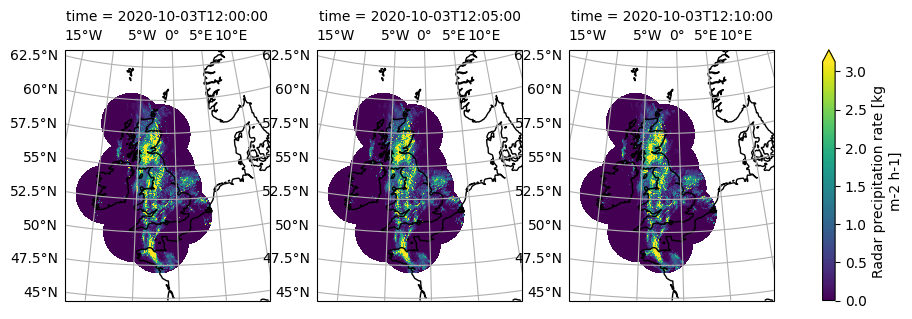

In [4]:
var_name = "RR"

crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

g = (
    ds[var_name]
    .sel(time="2020-10-03T12")
    .isel(time=slice(None, 3))
    .plot(
        transform=data_crs,
        cmap="viridis",
        add_colorbar=True,
        col="time",
        robust=True,
        subplot_kws=dict(projection=data_crs),
        vmin=0,
    )
)

for ax in g.axs.flat:
    ax.coastlines()
    ax.gridlines(draw_labels=["top", "left"])